# ANÁLISIS DE SERIES DE TIEMPO: GAS NATURAL Y PETRÓLEO CRUDO
### Econometría — Prueba de Cointegración de Johansen, VAR, VECM y ARDL
**Series:** Gas Natural Futures (NG=F) y Petróleo Crudo Futures (CL=F)  
**Período:** 2022-01-01 a 2026-03-09

## 1. DESCARGA Y PREPARACIÓN DE DATOS

In [1]:
# INSTALACION DE LIBRERIAS
!pip install yfinance arch statsmodels -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.7 MB/s eta 0:00:00


In [2]:
# IMPORTACION DE LIBRERIAS
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
# DESCARGA DE DATOS: GAS NATURAL (Y) Y PETROLEO CRUDO (X)
D = yf.download("NG=F", start="2022-01-01", end="2026-03-09")
P = yf.download("CL=F", start="2022-01-01", end="2026-03-09")

# EXTRACCION DE PRECIOS DE CIERRE
Y = D["Close"]   # Gas Natural
X = P["Close"]   # Petroleo Crudo

print("Observaciones Gas Natural:", len(Y))
print("Observaciones Petroleo:   ", len(X))

/tmp/ipykernel_20956/643384606.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  D = yf.download("NG=F", start="2022-01-01", end="2026-03-09")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_20956/643384606.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  P = yf.download("CL=F", start="2022-01-01", end="2026-03-09")
[*********************100%***********************]  1 of 1 completed

Observaciones Gas Natural: 1050
Observaciones Petroleo:    1049


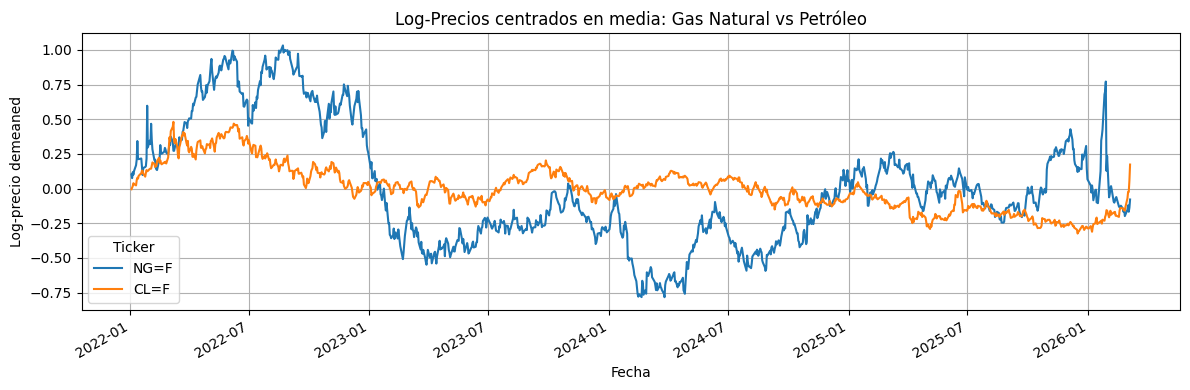

In [4]:
# SACAR LOGARITMO DE LAS SERIES
LY = np.log(Y)   # Log Gas Natural
LX = np.log(X)   # Log Petroleo Crudo

# PLOTEO DE LOS DATOS EN LA MISMA ESCALA
_ = (pd.concat([LY, LX], axis=1).dropna() - pd.concat([LY, LX], axis=1).dropna().mean()).plot(
    title="Log-Precios centrados en media: Gas Natural vs Petróleo",
    figsize=(12, 4)
)
plt.xlabel("Fecha")
plt.ylabel("Log-precio demeaned")
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. PRUEBAS DE RAÍZ UNITARIA
> **Objetivo:** Verificar que ambas series son I(1) antes de aplicar Johansen.

### 2.1 Serie en NIVELES — Log Gas Natural (LY)

In [5]:
from arch.unitroot import ADF

# SIN CONSTANTE NI TENDENCIA
adf = ADF(LY.dropna(), trend='n')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -0.761
P-value                         0.387
Lags                                2
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [6]:
# CON CONSTANTE
adf = ADF(LY.dropna(), trend='c')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -2.017
P-value                         0.279
Lags                                2
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [7]:
# CON CONSTANTE Y TENDENCIA
adf = ADF(LY.dropna(), trend='ct')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -2.175
P-value                         0.504
Lags                                2
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.41 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [8]:
from arch.unitroot import PhillipsPerron

# PHILLIPS-PERRON SIN CONSTANTE
pp = PhillipsPerron(LY.dropna(), trend='n')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -0.696
P-value                         0.414
Lags                               22
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [9]:
# PHILLIPS-PERRON CON CONSTANTE
pp = PhillipsPerron(LY.dropna(), trend='c')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -1.905
P-value                         0.330
Lags                               22
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [10]:
# PHILLIPS-PERRON CON CONSTANTE Y TENDENCIA
pp = PhillipsPerron(LY.dropna(), trend='ct')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -2.078
P-value                         0.558
Lags                               22
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.41 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [11]:
from arch.unitroot import KPSS

# KPSS CON CONSTANTE (H0: estacionaria)
kpss = KPSS(LY.dropna(), trend='c')
print(kpss.summary().as_text())

    KPSS Stationarity Test Results   
Test Statistic                  1.548
P-value                         0.000
Lags                               19
-------------------------------------

Trend: Constant
Critical Values: 0.74 (1%), 0.46 (5%), 0.35 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_20956/2529944567.py:4: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(LY.dropna(), trend='c')


In [12]:
# KPSS CON CONSTANTE Y TENDENCIA
kpss = KPSS(LY.dropna(), trend='ct')
print(kpss.summary().as_text())

    KPSS Stationarity Test Results   
Test Statistic                  0.847
P-value                         0.000
Lags                               19
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: 0.22 (1%), 0.15 (5%), 0.12 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_20956/2633671811.py:2: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(LY.dropna(), trend='ct')


> **Interpretación LY (niveles):**
> - ADF y PP: p-valor > 0.05 → **NO se rechaza H₀** → hay raíz unitaria
> - KPSS: p-valor < 0.05 → **Se rechaza H₀** de estacionariedad → confirma no estacionariedad
> - **Conclusión: LY es NO estacionaria en niveles**

### 2.2 Serie en NIVELES — Log Petróleo (LX)

In [13]:
# ADF - LOG PETROLEO EN NIVELES
adf = ADF(LX.dropna(), trend='n')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -0.062
P-value                         0.663
Lags                               10
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [14]:
adf = ADF(LX.dropna(), trend='c')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -1.926
P-value                         0.320
Lags                                6
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [15]:
adf = ADF(LX.dropna(), trend='ct')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -2.860
P-value                         0.176
Lags                                6
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.41 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [16]:
# PP - LOG PETROLEO EN NIVELES
pp = PhillipsPerron(LX.dropna(), trend='n')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                  0.193
P-value                         0.745
Lags                               22
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [17]:
pp = PhillipsPerron(LX.dropna(), trend='c')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -2.050
P-value                         0.265
Lags                               22
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [18]:
pp = PhillipsPerron(LX.dropna(), trend='ct')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -3.361
P-value                         0.057
Lags                               22
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.41 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [19]:
# KPSS - LOG PETROLEO EN NIVELES
kpss = KPSS(LX.dropna(), trend='c')
print(kpss.summary().as_text())

    KPSS Stationarity Test Results   
Test Statistic                  3.707
P-value                         0.000
Lags                               19
-------------------------------------

Trend: Constant
Critical Values: 0.74 (1%), 0.46 (5%), 0.35 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_20956/3945737967.py:2: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(LX.dropna(), trend='c')


In [20]:
kpss = KPSS(LX.dropna(), trend='ct')
print(kpss.summary().as_text())

    KPSS Stationarity Test Results   
Test Statistic                  0.206
P-value                         0.013
Lags                               19
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: 0.22 (1%), 0.15 (5%), 0.12 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_20956/2869107868.py:1: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(LX.dropna(), trend='ct')


### 2.3 PRIMERA DIFERENCIA — DLY y DLX

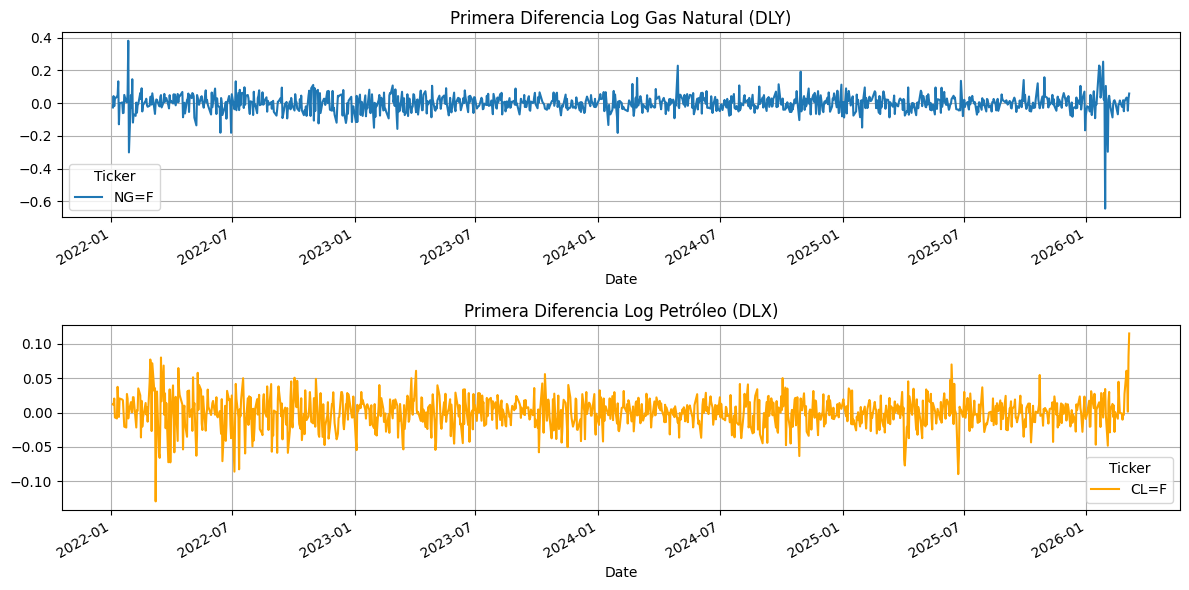

In [21]:
# PRIMERA DIFERENCIA DE AMBAS SERIES
DLY = LY.diff().dropna()
DLX = LX.diff().dropna()

# GRAFICA DE LAS PRIMERAS DIFERENCIAS
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
DLY.plot(ax=axes[0], title="Primera Diferencia Log Gas Natural (DLY)", grid=True)
DLX.plot(ax=axes[1], title="Primera Diferencia Log Petróleo (DLX)", color='orange', grid=True)
plt.tight_layout()
plt.show()

In [22]:
# ADF EN PRIMERA DIFERENCIA - GAS NATURAL
print("=== DLY (Gas Natural) ===")
for trend in ['n','c','ct']:
    adf = ADF(DLY, trend=trend)
    print(f"trend='{trend}': Estadístico={adf.stat:.4f}, p-valor={adf.pvalue:.4f}")

=== DLY (Gas Natural) ===
trend='n': Estadístico=-22.7293, p-valor=0.0000
trend='c': Estadístico=-22.7188, p-valor=0.0000
trend='ct': Estadístico=-22.7077, p-valor=0.0000


In [23]:
# ADF EN PRIMERA DIFERENCIA - PETROLEO
print("=== DLX (Petróleo) ===")
for trend in ['n','c','ct']:
    adf = ADF(DLX, trend=trend)
    print(f"trend='{trend}': Estadístico={adf.stat:.4f}, p-valor={adf.pvalue:.4f}")

=== DLX (Petróleo) ===
trend='n': Estadístico=-12.0572, p-valor=0.0000
trend='c': Estadístico=-12.0487, p-valor=0.0000
trend='ct': Estadístico=-12.0357, p-valor=0.0000


In [24]:
# KPSS EN PRIMERA DIFERENCIA
print("=== KPSS DLY ===")
kpss = KPSS(DLY, trend='c')
print(kpss.summary().as_text())

print("=== KPSS DLX ===")
kpss = KPSS(DLX, trend='c')
print(kpss.summary().as_text())

=== KPSS DLY ===
    KPSS Stationarity Test Results   
Test Statistic                  0.057
P-value                         0.833
Lags                                2
-------------------------------------

Trend: Constant
Critical Values: 0.74 (1%), 0.46 (5%), 0.35 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.
=== KPSS DLX ===
    KPSS Stationarity Test Results   
Test Statistic                  0.087
P-value                         0.652
Lags                                0
-------------------------------------

Trend: Constant
Critical Values: 0.74 (1%), 0.46 (5%), 0.35 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_20956/638565137.py:3: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(DLY, trend='c')
/tmp/ipykernel_20956/638565137.py:7: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(DLX, trend='c')


> **Interpretación primera diferencia:**
> - ADF y PP: p-valor ≈ 0.000 → **Se rechaza H₀** → no hay raíz unitaria
> - KPSS: p-valor > 0.05 → **No se rechaza H₀** de estacionariedad
> - **Conclusión: DLY y DLX son I(0) → LY y LX son I(1) ✓**
> - **Ambas series son I(1): se puede aplicar la prueba de Johansen**

## 3. PRUEBA DE COINTEGRACIÓN DE JOHANSEN

In [25]:
# CONSTRUCCION DE LA MATRIZ H (series en niveles)
H = pd.concat([LY, LX], axis=1).dropna()
H.columns = ["LGasNatural", "LPetroleo"]
H.head()

,LGasNatural,LPetroleo
Date,,
2022-01-03,1.338941,4.331785
2022-01-04,1.312917,4.343676
2022-01-05,1.356350,4.354784
2022-01-06,1.338154,4.375254
2022-01-07,1.365071,4.368181


In [26]:
# REZAGO OPTIMO PARA PRUEBA DE JOHANSEN
from statsmodels.tsa.vector_ar.vecm import select_order

RO = select_order(H, maxlags=5, deterministic="co")
RO.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-13.27,-13.23*,1.725e-06,-13.26
1,-13.29,-13.23,1.699e-06,-13.26*
2,-13.29*,-13.21,1.692e-06*,-13.26
3,-13.28,-13.19,1.704e-06,-13.25
4,-13.28,-13.17,1.700e-06,-13.24
5,-13.28,-13.15,1.701e-06,-13.23


In [27]:
# PRUEBA DE COINTEGRACIÓN DE JOHANSEN
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# FUNCION PARA MOSTRAR RESULTADOS DE JOHANSEN (estructura de clase)
def jon_output(res):
    output = pd.DataFrame([res.lr2, res.lr1], index=["max_eig_stat", "trace_stat"])
    print(output.T, "\n")
    print("valor critico (90%, 95%, 99%) de max_eig_stat Ho: r=0 y Ho: r=1\n", res.cvm, "\n")
    print("valor critico (90%, 95%, 99%) de trace_stat Ho: r=0 y Ho: r=1\n", res.cvt, "\n")

# FUNCION DE COINTEGRACION (variables, 0:con constante, rezago optimo)
# Nota: usar el rezago optimo del select_order (k_ar_diff = p-1)
jon_model = coint_johansen(H, 0, 1)
jon_output(jon_model)

   max_eig_stat  trace_stat
0      6.693760   10.219969
1      3.526209    3.526209 

valor critico (90%, 95%, 99%) de max_eig_stat Ho: r=0 y Ho: r=1
 [[12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]] 

valor critico (90%, 95%, 99%) de trace_stat Ho: r=0 y Ho: r=1
 [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]] 



> **Cómo leer los resultados de Johansen:**
>
> **Prueba de Traza (trace_stat):** H₀: el número de vectores cointegrantes es ≤ r
> - Si trace_stat > valor crítico al 95% → rechazar H₀ → hay más de r vectores
> - Empezar desde r=0 y subir hasta NO rechazar → ese es el rango de cointegración
>
> **Prueba de Máximo Eigenvalor (max_eig_stat):** H₀: hay exactamente r vectores
> - Misma lógica secuencial
>
> **Resultado:**
> - Si r=1 → hay 1 relación de largo plazo → usar **VECM**
> - Si r=0 → no hay cointegración → usar **VAR en diferencias**

## 4. MODELO VECTOR AUTORREGRESIVO (VAR)
> Se estima en **primera diferencia** porque las series son I(1)

In [28]:
from statsmodels.tsa.api import VAR

# PRIMERA DIFERENCIA DE H
G = H.diff().dropna()
G.head()

,LGasNatural,LPetroleo
Date,,
2022-01-04,-0.026024,0.011890
2022-01-05,0.043434,0.011108
2022-01-06,-0.018196,0.020470
2022-01-07,0.026917,-0.007072
2022-01-10,0.040781,-0.008528


In [29]:
# CONFIGURA EL MODELO VAR
model = VAR(G)

# SE OPERA EL MODELO VAR CON REZAGO OPTIMO
resultadoVAR = model.fit(3)
print(resultadoVAR.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 20, Apr, 2026
Time:                     18:43:11
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -13.2202
Nobs:                     1045.00    HQIC:                  -13.2614
Log likelihood:           3990.65    FPE:                1.69713e-06
AIC:                     -13.2866    Det(Omega_mle):     1.67462e-06
--------------------------------------------------------------------
Results for equation LGasNatural
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                 -0.000194         0.001719           -0.113           0.910
L1.LGasNatural        -0.117872         0.031170           -3.782           0.000
L1.LPetroleo           0.109752         0.074801  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## 5. MODELO DE VECTOR DE CORRECCIÓN DE ERRORES (VECM)
> Se usa cuando existe cointegración (r ≥ 1). Captura la dinámica de corto y largo plazo.

In [30]:
from statsmodels.tsa.api import VECM

# SE CONFIGURA EL MODELO VEC
# k_ar_diff: rezago optimo - 1
# coint_rank: numero de vectores de cointegracion encontrado en Johansen
# deterministic='co': constante dentro de la relacion de cointegracion
modeloVEC = VECM(H, k_ar_diff=3, coint_rank=1, deterministic='co')

# SE OPERA EL MODELO VEC
resultadoVEC = modeloVEC.fit()

# IMPRIME TABLA DE RESULTADOS VEC
print(resultadoVEC.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation LGasNatural
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0746      0.042     -1.777      0.076      -0.157       0.008
L1.LGasNatural    -0.1152      0.031     -3.711      0.000      -0.176      -0.054
L1.LPetroleo       0.0991      0.075      1.326      0.185      -0.047       0.245
L2.LGasNatural     0.0693      0.031      2.222      0.026       0.008       0.130
L2.LPetroleo      -0.1738      0.075     -2.315      0.021      -0.321      -0.027
L3.LGasNatural     0.0015      0.031      0.047      0.962      -0.059       0.062
L3.LPetroleo      -0.0165      0.075     -0.220      0.826      -0.164       0.131
Det. terms outside the coint. relation & lagged endog. parameters for equation LPetroleo
                     coef    std err          z      P>|z|      [0.025   

In [31]:
# RECUPERA INNOVACIÓN DEL MODELO VEC
INN_TOTAL_VECN = resultadoVEC.resid
INN_TOTAL_VEC = pd.DataFrame(INN_TOTAL_VECN, columns=['LGasNatural','LPetroleo'])
INN_TOTAL_VEC.head()

,LGasNatural,LPetroleo
0,0.022004,-0.007957
1,0.049871,-0.007426
2,0.044398,0.036544
3,0.130548,0.013144
4,-0.110876,-0.009645


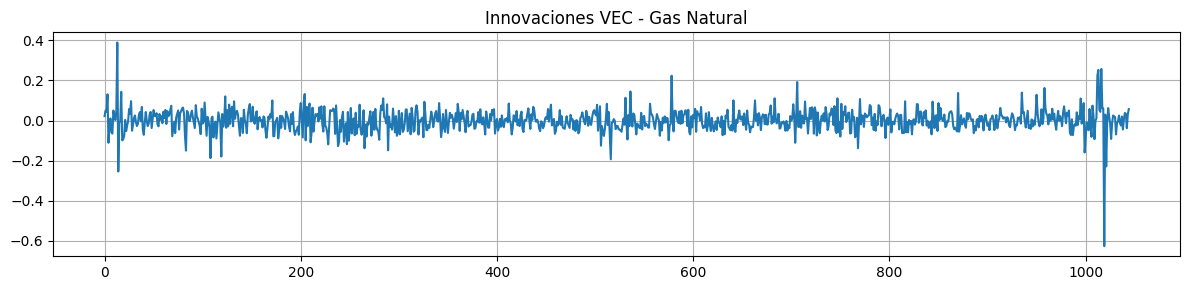

In [32]:
# SELECCION DE LA INNOVACIÓN DE LA VARIABLE DE ANALISIS PRINCIPAL (GAS NATURAL)
INN_Y_VEC = INN_TOTAL_VEC["LGasNatural"]
INN_Y_VEC.plot(title="Innovaciones VEC - Gas Natural", figsize=(12, 3), grid=True)
plt.tight_layout()
plt.show()

### 5.1 CONTRASTES DE ESPECIFICACIÓN VEC

#### PRUEBA DE AUTOCORRELACIÓN VEC
> H₀: No hay autocorrelación — se desea NO rechazar (p-valor > 0.05)

In [33]:
# PRUEBA DE AUTOCORRELACION SOBRE RESIDUOS
sm.stats.acorr_ljungbox(INN_Y_VEC, lags=[3], return_df=True)

,lb_stat,lb_pvalue
3,0.109861,0.990628


In [34]:
# PRUEBA DE EFECTO ARCH (autocorrelacion en residuos al cuadrado)
# H0: NO HAY EFECTO ARCH
INN_Y2_VEC = INN_Y_VEC * INN_Y_VEC
sm.stats.acorr_ljungbox(INN_Y2_VEC, lags=[3], return_df=True)

,lb_stat,lb_pvalue
3,31.898797,5.496889e-07


#### PRUEBA DE NORMALIDAD VEC
> H₀: Los residuos tienen distribución normal — se desea NO rechazar (p-valor > 0.05)

In [35]:
from scipy.stats import normaltest
JB = normaltest(INN_Y_VEC)
JB

NormaltestResult(statistic=np.float64(386.76266048770236), pvalue=np.float64(1.036466744177027e-84))

#### ANÁLISIS DE IMPULSO RESPUESTA VEC

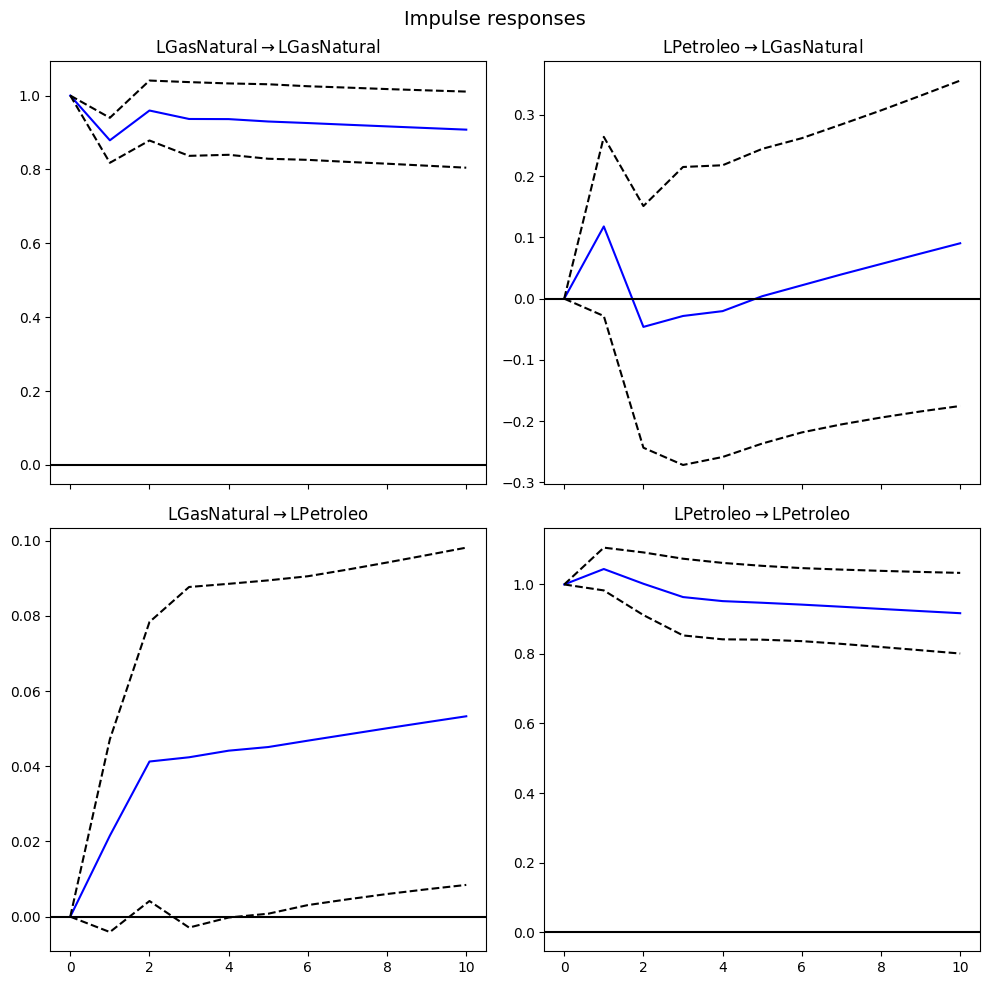

In [36]:
# IMPULSO-RESPUESTA
irfVEC = resultadoVEC.irf(10)
irfVEC.plot(orth=False)
plt.tight_layout()
plt.show()

## 6. MODELO ARDL (Autoregressive Distributed Lag)
> El modelo ARDL es una alternativa a Johansen para detectar cointegración.  
> Trabaja con las **series en niveles** (no requiere que sean del mismo orden de integración).  
> **Y** = Log Gas Natural (dependiente) | **X** = Log Petróleo (independiente)

In [37]:
import pandas as pd
# MODELO ARDL - LIBRERIA
from statsmodels.tsa.api import ARDL

# SELECCION DEL ORDEN DEL ARDL - LIBRERIA
from statsmodels.tsa.ardl import ardl_select_order

# Alinear Y y X
Y_ardl_series = LY['NG=F'].dropna() # Explicitly select the 'NG=F' column (Series)
X_ardl_series = LX['CL=F'].dropna() # Explicitly select the 'CL=F' column (Series)

# Align the series to ensure they have the same index and length
Y_ardl_aligned, X_ardl_aligned = Y_ardl_series.align(X_ardl_series, join='inner')

# Convert the aligned series to DataFrames for ardl_select_order
Y_ardl = Y_ardl_aligned.to_frame(name='NG=F')
X_ardl = X_ardl_aligned.to_frame(name='CL=F')

# SELECCION DEL ORDEN DEL ARDL
sel_res = ardl_select_order(Y_ardl, 5, X_ardl, 5, ic="aic", trend="c")
print(f"El orden óptimo para Y; X: {sel_res.model.ardl_order}")

El orden óptimo para Y; X: (3, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [38]:
# CONFIGURACIÓN DEL MODELO ARDL CON EL ORDEN SELECCIONADO
# Usar el orden encontrado por sel_res, ejemplo (5, 4) -> ARDL(Y, 5, X, 4)
p_ardl, q_ardl = sel_res.model.ardl_order
modARDL12 = ARDL(Y_ardl, p_ardl, X_ardl, q_ardl)

# OPERACIÓN DEL MODELO
ARDL12 = modARDL12.fit()
print(ARDL12.summary())

                              ARDL Model Results                              
Dep. Variable:                   NG=F   No. Observations:                 1049
Model:                     ARDL(3, 5)   Log Likelihood                1552.723
Method:               Conditional MLE   S.D. of innovations              0.055
Date:                Mon, 20 Apr 2026   AIC                          -3083.447
Time:                        18:43:15   BIC                          -3028.967
Sample:                             5   HQIC                         -3062.786
                                 1049                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0589      0.049     -1.212      0.226      -0.154       0.036
NG=F.L1        0.8726      0.031     28.160      0.000       0.812       0.933
NG=F.L2        0.1791      0.041      4.395      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### 6.1 CONTRASTES DE ESPECIFICACIÓN ARDL

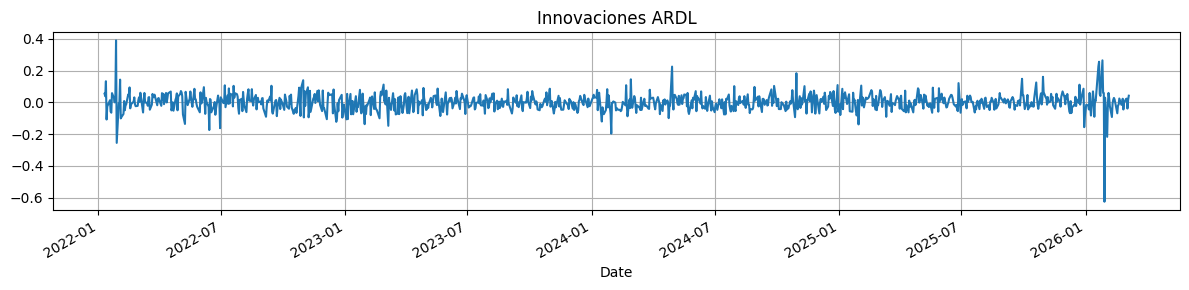

In [39]:
# CONTRASTES DE ESPECIFICACION
# RECUPERACIÓN DE LA INNOVACIÓN
INN_ARDL = ARDL12.resid
INN_ARDL.plot(title="Innovaciones ARDL", figsize=(12, 3), grid=True)
plt.tight_layout()
plt.show()

In [40]:
## PRUEBA DE AUTOCORRELACIÓN ARDL
# H0: NO HAY AUTOCORRELACION
sm.stats.acorr_ljungbox(INN_ARDL, lags=[5], return_df=True)

,lb_stat,lb_pvalue
5,3.289888,0.65539


In [41]:
## PRUEBA DE EFECTO ARCH ARDL
# H0: NO HAY EFECTO ARCH
INN_ARDL2 = INN_ARDL * INN_ARDL
sm.stats.acorr_ljungbox(INN_ARDL2, lags=[5], return_df=True)

,lb_stat,lb_pvalue
5,34.802086,0.000002


In [42]:
# PRUEBA DE NORMALIDAD ARDL
# H0: INN_ARDL TIENE DISTRIBUCIÓN NORMAL
from scipy.stats import normaltest
JB = normaltest(INN_ARDL)
print(JB)

NormaltestResult(statistic=np.float64(380.2505184334144), pvalue=np.float64(2.6893606850001696e-83))


### 6.2 MODELO ARDL DE CORRECCIÓN DE ERRORES (ECM)

In [43]:
# ACTIVACION DE LA LIBRERIA DE ARDL EN CORRECCIÓN DE ERRORES
from statsmodels.tsa.api import UECM

# MODELO ARDL DE CORRECCION DE ERRORES DESDE UN MODELO ARDL
ecm = UECM.from_ardl(modARDL12)
ecm_res = ecm.fit()
print(ecm_res.summary())

                              UECM Model Results                              
Dep. Variable:                 D.NG=F   No. Observations:                 1049
Model:                     UECM(3, 5)   Log Likelihood                1548.755
Method:               Conditional MLE   S.D. of innovations              1.310
Date:                Mon, 20 Apr 2026   AIC                          -3075.511
Time:                        18:43:15   BIC                          -3021.052
Sample:                             5   HQIC                         -3054.856
                                 1049                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0589      0.049     -1.212      0.226      -0.154       0.036
NG=F.L1       -0.0105      0.004     -2.375      0.018      -0.019      -0.002
CL=F.L1        0.0165      0.012      1.417      0.1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [44]:
# COMPONENTE DE LA CORRECCIÓN DE ERROR
print(ecm_res.ci_summary())

                             Cointegrating Vector                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6042      4.465      1.255      0.209      -3.157      14.365
NG=F.L1        1.0000          0        nan        nan       1.000       1.000
CL=F.L1       -1.5720      1.028     -1.529      0.126      -3.590       0.446


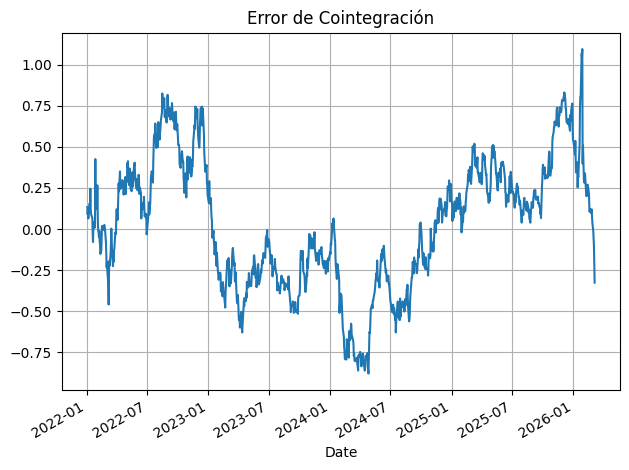

In [45]:
# GRAFICA DE LOS RESIDUOS DE LA CORRECCION DE ERROR
_ = ecm_res.ci_resids.plot(title="Error de Cointegración")
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.3 CONTRASTES DE ESPECIFICACIÓN ECM-ARDL

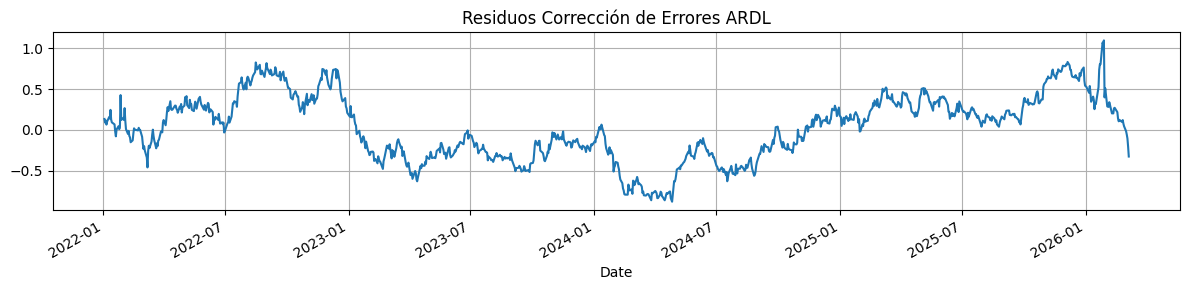

In [46]:
# LIBRERIA PARA LA PRUEBA LJUNG-BOX
import statsmodels.api as sm

# RECUPERACION RESIDUALES CORRECCION DE ERRORES
INN_CE = ecm_res.ci_resids
INN_CE.plot(title="Residuos Corrección de Errores ARDL", figsize=(12, 3), grid=True)
plt.tight_layout()
plt.show()

In [47]:
# PRUEBA DE AUTOCORRELACIÓN ARDL
# H0: NO HAY AUTOCORRELACION
sm.stats.acorr_ljungbox(INN_CE, lags=[1], return_df=True)

,lb_stat,lb_pvalue
1,1023.673324,1.284098e-224


In [48]:
# PRUEBA DE EFECTO ARCH ARDL
# H0: NO HAY EFECTO ARCH
INN_CE2 = INN_CE * INN_CE
sm.stats.acorr_ljungbox(INN_CE2, lags=[1], return_df=True)

,lb_stat,lb_pvalue
1,946.691515,6.949087e-208


In [49]:
# PRUEBA DE NORMALIDAD ARDL
# H0: INN_ARDL TIENE DISTRIBUCIÓN NORMAL
from scipy.stats import normaltest
JBCE = normaltest(INN_CE)
JBCE

NormaltestResult(statistic=np.float64(42.77147250811261), pvalue=np.float64(5.15576071975443e-10))